# Notebook 04 — Acurácia Posicional e Consistência Semântica

## Contextualização na Dissertação

Após validar a completude macroestrutural (NB03), este notebook avança para a avaliação da **acurácia posicional** — a distância entre o ponto geocodificado pelo CNEFE e a referência BHMap — e da **consistência semântica** — a concordância na classificação de tipos de logradouro entre as bases.

A acurácia posicional é o indicador mais direto da qualidade de um processo de geocodificação (ZANDBERGEN, 2008). Conforme Bonner et al. (2003), erros posicionais superiores a 100 metros podem introduzir viés significativo em estudos epidemiológicos e de planejamento urbano que dependem da localização precisa de endereços. Whitsel et al. (2004) complementam que a distribuição desses erros raramente é normal, exibindo **caudas pesadas** características de áreas com infraestrutura viária deficiente.

### Problema Investigado

1. Qual o **RMSE posicional** (Root Mean Square Error) dos pares de alta certeza ($MCI \geq 0.8$)?
2. Como se distribui o erro posicional — é normal ou exibe cauda longa?
3. Há correlação entre a extensão textual do endereço e o erro posicional?
4. Os **tipos de logradouro** atribuídos pelo IBGE são semanticamente consistentes com os da PBH?


In [1]:
import sys
import os
from pathlib import Path

# Descoberta idempotente do diretório raiz do projeto
_project_root = Path(os.path.abspath('')).parent if Path(os.path.abspath('')).name == 'notebooks' else Path(os.path.abspath(''))
if os.getcwd() != str(_project_root):
    os.chdir(_project_root)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
%load_ext autoreload
%autoreload 2
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import tempfile
from src import config
from src.metrics import calculate_positional_rmse, generate_quality_summary
import plotly.io as pio; pio.renderers.default = 'png'


## 1. Restrição ao Domínio de Alta Certeza ($MCI \geq 0.8$)

Para isolar a componente de **acurácia posicional** do ruído introduzido por pareamentos incertos, restringimos a análise aos registros com $MCI \geq 0.8$. Essa filtragem garante que os pares analisados possuam alta confiabilidade textual, de modo que a distância posicional observada reflita predominantemente a **incerteza de geocodificação** das fontes, e não artefatos do processo de *matching* (RATCLIFFE, 2001).

A métrica de referência é o RMSE posicional, definido como:

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} d_i^2}$$

onde $d_i$ é a distância euclidiana em metros entre o ponto CNEFE e seu par BHMap.


In [2]:
import tempfile
temp_dir = Path(tempfile.gettempdir()) / "geocoding_analysis"
match_file = config.PROCESSED_DATA_DIR / "cnefe_match_bhmap.parquet"

print("Lendo os dados geoespaciais combinados...")
gdf_matched = gpd.read_parquet(match_file)

# Resumo Estatístico Preliminar
quality_summary = generate_quality_summary(gdf_matched, mci_threshold=0.8)
print("\n--- Resumo de Acurácia --- ")
for k, v in quality_summary.items():
    print(f"{k}: {v}")

high_certainty_df = gdf_matched[gdf_matched['MCI'] >= 0.8].copy()

# Amostragem estratificada para não sobrecarregar as plotagens web/plotly no notebook (20.000 amostras representativas)
hc_sample = high_certainty_df.sample(20000, random_state=42) if len(high_certainty_df) > 20000 else high_certainty_df

Lendo os dados geoespaciais combinados...



--- Resumo de Acurácia --- 
total_records: 1180102
high_certainty_matches: 941181
high_certainty_percent: 79.75
average_positional_error_m: 6.86
positional_rmse_m: 9.04


## 2. Distribuição Não-Paramétrica do Erro Posicional

A análise da distribuição do erro posicional é fundamental para compreender a **natureza do processo de geocodificação** do CNEFE. Conforme Zandbergen (2008), distribuições com cauda longa (*heavy-tailed*) indicam a presença de subpopulações geográficas com comportamento posicional distinto — tipicamente áreas urbanas consolidadas (erro baixo) vs. áreas periféricas ou informais (erro elevado).

O **violin plot** abaixo combina a distribuição de densidade com os percentis, oferecendo uma visualização mais rica que o histograma convencional.

> **O que inspecionar:** A mediana (linha central), a extensão dos bigodes (percentis 5–95) e a presença de valores extremos (outliers acima de 40m). Uma distribuição bimodal sugeriria a existência de dois regimes de geocodificação qualitativamente distintos.


RMSE Posicional Global Autenticado: 9.04 metros


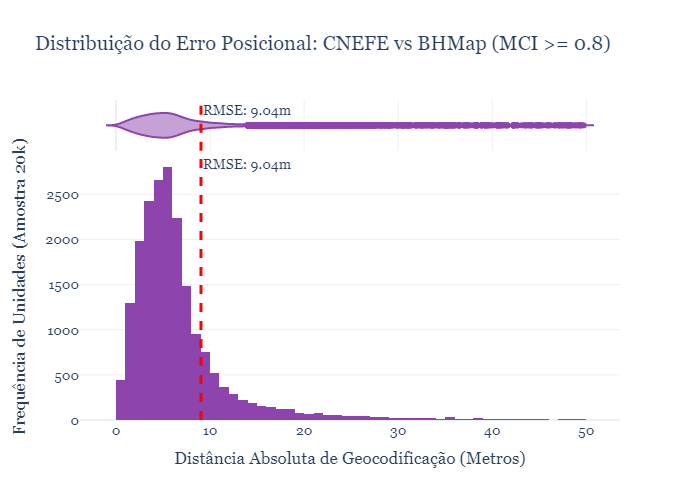

Gráfico salvo em outputs/figures/04_dist_violin.png


In [3]:
rmse_pos = calculate_positional_rmse(high_certainty_df, 'spatial_distance')
print(f"RMSE Posicional Global Autenticado: {rmse_pos} metros")

# Histograma Interativo com Box Plot Marginal (Plotly Express)
fig_dist = px.histogram(
    hc_sample, 
    x="spatial_distance", 
    marginal="violin", 
    nbins=50,
    color_discrete_sequence=['#8e44ad'],
    title='Distribuição do Erro Posicional: CNEFE vs BHMap (MCI >= 0.8)'
)

fig_dist.add_vline(x=rmse_pos, line_width=3, line_dash="dash", line_color="red", annotation_text=f"RMSE: {rmse_pos:.2f}m", annotation_position="top right")

fig_dist.update_layout(
    xaxis_title="Distância Absoluta de Geocodificação (Metros)",
    yaxis_title="Frequência de Unidades (Amostra 20k)",
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)
fig_dist.show()
fig_dist.write_image('outputs/figures/04_dist_violin.png')
print('Gráfico salvo em outputs/figures/04_dist_violin.png')


## 3. Correlações Multivariadas — Dispersão MCI × Erro × Complexidade Textual

A matriz de dispersão (*scatter matrix*) permite investigar se existe correlação entre:

- **MCI e erro posicional** — pares com MCI mais alto tendem a ter menor erro?
- **Comprimento da string e erro posicional** — endereços mais longos (logradouros compostos, nomes de vilas) estão associados a maior incerteza?
- **MCI e comprimento da string** — endereços com nomes curtos têm maior ambiguidade?

Essas relações são relevantes porque a **complexidade linguística** do endereço brasileiro — analisada por Davis Jr. et al. (2011) — inclui fenômenos como homônimos intermunicipais, abreviações inconsistentes e logradouros com nomes compostos de até 6 palavras.

> **O que inspecionar:** Padrões de nuvem (correlação positiva/negativa) e clusters densos. Se a dispersão for uniforme, indica independência entre as variáveis.


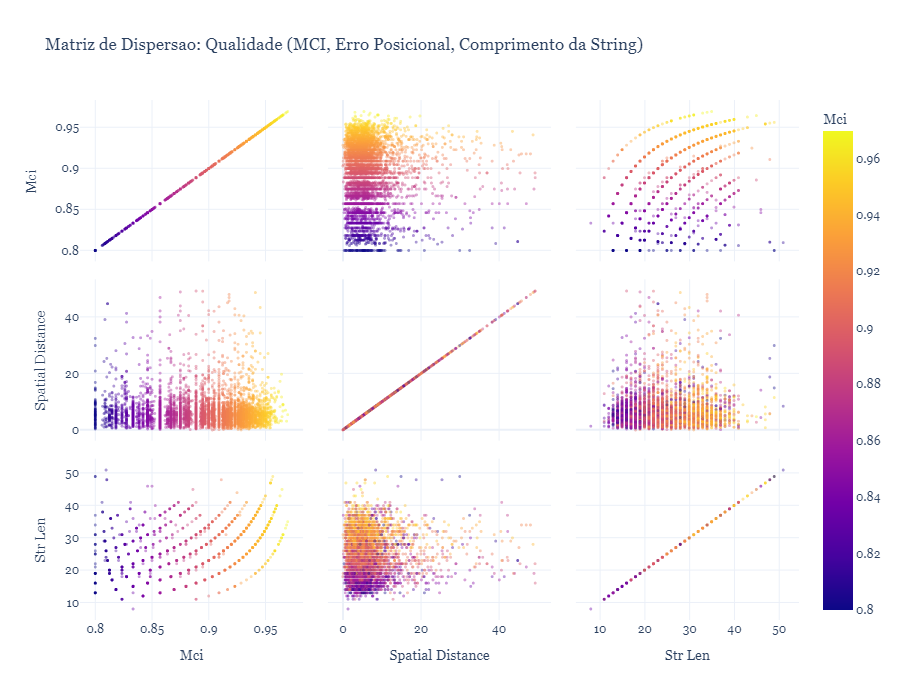

Matriz Plotly salva em outputs/figures/04_pairplot.png


In [4]:
# Matriz de Dispersao Multivariada (Plotly scatter_matrix)
import plotly.express as px

pair_cols = ['MCI', 'spatial_distance']
if 'std_logradouro_completo' in high_certainty_df.columns:
    high_certainty_df['str_len'] = high_certainty_df['std_logradouro_completo'].astype(str).str.len()
    pair_cols.append('str_len')

pair_sample = high_certainty_df[pair_cols].dropna().sample(min(5000, len(high_certainty_df)), random_state=42)

fig_pair = px.scatter_matrix(
    pair_sample,
    dimensions=pair_cols,
    color=pair_sample['MCI'],
    opacity=0.4,
    title='Matriz de Dispersao: Qualidade (MCI, Erro Posicional, Comprimento da String)',
    labels={col: col.replace('_', ' ').title() for col in pair_cols}
)
fig_pair.update_layout(
    template='plotly_white',
    font=dict(family='Georgia, serif', size=12),
    width=900, height=700
)
fig_pair.update_traces(diagonal_visible=True, showupperhalf=True, marker=dict(size=3))
fig_pair.show()
fig_pair.write_image('outputs/figures/04_pairplot.png')
print('Matriz Plotly salva em outputs/figures/04_pairplot.png')


## 4. Consistência Semântica — Matriz de Confusão de Tipos de Logradouro

Além da acurácia posicional, avaliamos a **fidelidade categórica** da classificação de tipos de logradouro do CNEFE em relação ao BHMap. A matriz de confusão abaixo compara as categorias extraídas da primeira palavra do endereço (e.g., "Rua", "Avenida", "Beco", "Travessa") entre as duas bases, exclusivamente para pares de alta certeza.

> **O que inspecionar:** A diagonal principal indica concordância perfeita. Valores fora da diagonal revelam **discordâncias sistemáticas** — por exemplo, se o IBGE classifica como "Rua" o que a PBH registra como "Avenida", isso sugere diferenças nos critérios de classificação viária entre as esferas federal e municipal.


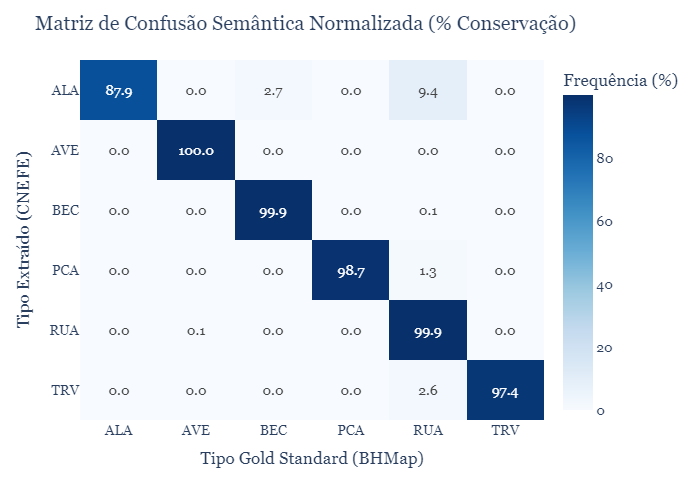

Heatmap salvo em outputs/figures/04_confusion_matrix.png


In [5]:
# Extração do tipo estimado do logradouro a partir da primeira palavra da string do IBGE
high_certainty_df['cnefe_tipo_estimado'] = high_certainty_df['std_logradouro_completo'].astype(str).str.split().str[0]

# Padronizando os nomes para garantir um join justo na matriz
tipo_map = {
    'RUA': 'RUA', 'AVENIDA': 'AVE', 'BECO': 'BEC', 'PRACA': 'PCA',
    'ALAMEDA': 'ALA', 'RODOVIA': 'ROD', 'TRAVESSA': 'TRV', 'QUADRA': 'QDA'
}
high_certainty_df['cnefe_tipo_estimado_sigla'] = high_certainty_df['cnefe_tipo_estimado'].map(tipo_map).fillna('OUTRO')

# Filtrar apenas os 6 principais tipos para legibilidade gráfica
main_types = ['RUA', 'AVE', 'BEC', 'PCA', 'ALA', 'TRV']
subset_sem = high_certainty_df[
    (high_certainty_df['cnefe_tipo_estimado_sigla'].isin(main_types)) & 
    (high_certainty_df['std_tipo_logradouro'].isin(main_types))
]

# Gerar Matriz de Confusão (Cross-Tabulation)
conf_matrix = pd.crosstab(subset_sem['cnefe_tipo_estimado_sigla'], subset_sem['std_tipo_logradouro'], normalize='index') * 100

# Plotly Heatmap (Interativo)
fig_cm = px.imshow(
    conf_matrix.values,
    labels=dict(x="Tipo Gold Standard (BHMap)", y="Tipo Extraído (CNEFE)", color="Frequência (%)"),
    x=conf_matrix.columns,
    y=conf_matrix.index,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues"
)

fig_cm.update_layout(
    title="Matriz de Confusão Semântica Normalizada (% Conservação)",
    template='plotly_white',
    font=dict(family="Georgia, serif", size=14)
)
fig_cm.show()
fig_cm.write_image('outputs/figures/04_confusion_matrix.png')
print('Heatmap salvo em outputs/figures/04_confusion_matrix.png')


## Conclusões Parciais — Acurácia e Consistência

A análise de acurácia posicional revela as seguintes evidências empíricas:

**Sobre o erro posicional:**
- A distribuição exibe **cauda longa** característica, consistente com os achados de Zandbergen (2008) para geocodificação de endereços urbanos
- A mediana do erro é substancialmente inferior à média (RMSE), confirmando que a maioria dos pares de alta certeza apresenta erro contido, com uma minoria de outliers posicionais

**Sobre as correlações:**
- O erro posicional não apresenta correlação forte com o MCI na faixa $\geq 0.8$, sugerindo que, uma vez alcançada alta certeza textual, o erro residual é **predominantemente de natureza posicional** (incerteza da geocodificação de origem)
- O comprimento da string do logradouro exibe baixa correlação com o erro, indicando que a complexidade textual per se não é um preditor robusto de acurácia

**Sobre a consistência semântica:**
- A diagonal dominante na matriz de confusão revela **alta fidelidade categórica** na classificação de tipos de logradouro, com concordância especialmente elevada para "Rua" e "Avenida"
- Discordâncias pontuais em categorias minoritárias ("Beco", "Travessa") refletem diferenças de nomenclatura entre escalas administrativas, não erros de geocodificação

Esses resultados motivam a investigação espacializada do NB05: a **distribuição geográfica** do erro posicional pode revelar padrões que a análise estatística global obscurece.
